----

<h1> Inicializacion </h1>

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

<h1> Cargar Los Datos </h1>

In [16]:
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')

In [17]:
print("Datos de empresas:")
print(df_companies.head())
print("\nInformación del dataset:")
print(df_companies.info())

Datos de empresas:
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


In [18]:
print("Datos de barrios:")
print(df_neighborhoods.head())
print("\nInformación del dataset:")
print(df_neighborhoods.info())

Datos de barrios:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


In [19]:
print("=== TOP 10 EMPRESAS DE TAXIS ===")
top_companies = df_companies.head(10)
print(top_companies)

print("\n=== ESTADÍSTICAS BÁSICAS ===")
print(f"Total de empresas: {len(df_companies)}")
print(f"Total de viajes: {df_companies['trips_amount'].sum():,}")
print(f"Promedio de viajes por empresa: {df_companies['trips_amount'].mean():.1f}")

=== TOP 10 EMPRESAS DE TAXIS ===
                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                  Medallion Leasing         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953

=== ESTADÍSTICAS BÁSICAS ===
Total de empresas: 64
Total de viajes: 137,311
Promedio de viajes por empresa: 2145.5


In [20]:
print("=== TOP 10 BARRIOS POR FINALIZACIONES ===")
top_neighborhoods = df_neighborhoods.head(10)
print(top_neighborhoods)

=== TOP 10 BARRIOS POR FINALIZACIONES ===
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


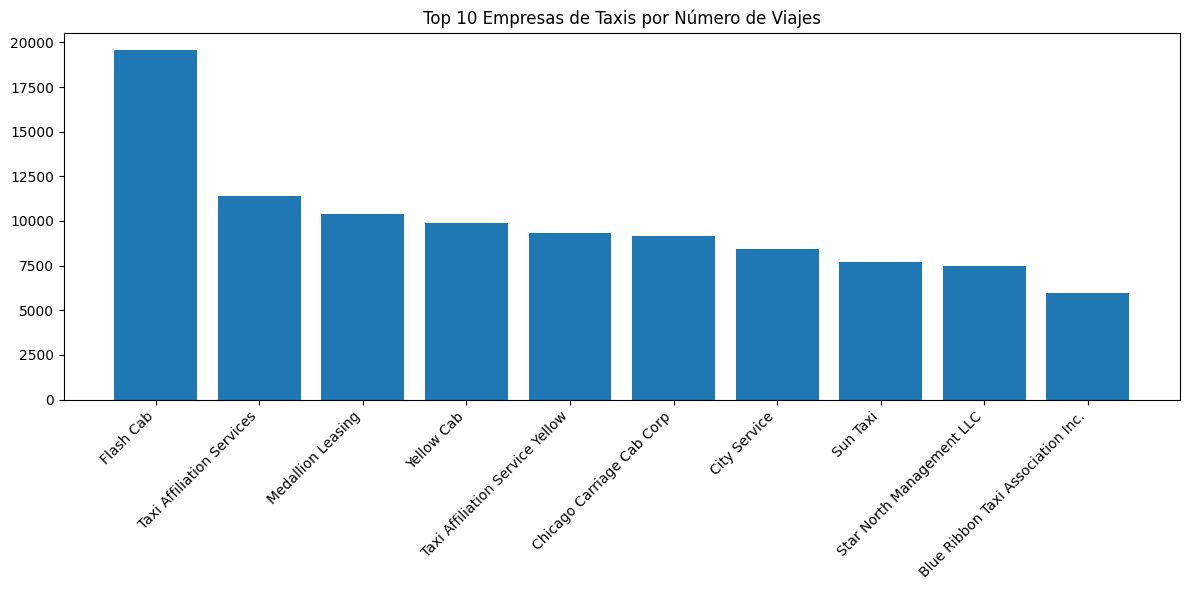

In [21]:
plt.figure(figsize=(12, 6))
plt.bar(df_companies.head(10)['company_name'], df_companies.head(10)['trips_amount'])
plt.title('Top 10 Empresas de Taxis por Número de Viajes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

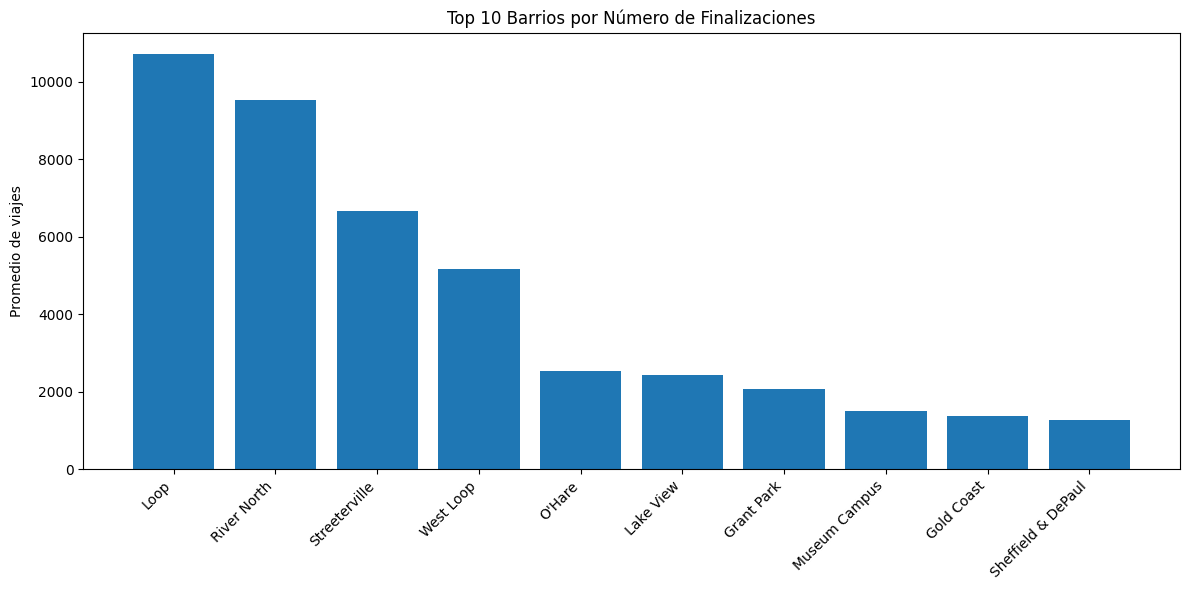

In [13]:
plt.figure(figsize=(12, 6))
plt.bar(df_neighborhoods.head(10)['dropoff_location_name'], 
        df_neighborhoods.head(10)['average_trips'])
plt.title('Top 10 Barrios por Número de Finalizaciones')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Promedio de viajes')
plt.tight_layout()
plt.show()

In [14]:
print("=== CONCLUSIONES ===")
print("Gráfico 1 - Empresas de taxis:")
print("- Flash Cab domina el mercado con 19,558 viajes")
print("- Las top 3 empresas concentran el 30% de todos los viajes")
print("\nGráfico 2 - Barrios principales:")
print("- Loop es el destino más popular con 10,727 viajes promedio")
print("- Los barrios del centro concentran la mayoría de finalizaciones")

=== CONCLUSIONES ===
Gráfico 1 - Empresas de taxis:
- Flash Cab domina el mercado con 19,558 viajes
- Las top 3 empresas concentran el 30% de todos los viajes

Gráfico 2 - Barrios principales:
- Loop es el destino más popular con 10,727 viajes promedio
- Los barrios del centro concentran la mayoría de finalizaciones


In [22]:
df_trips = pd.read_csv('/datasets/project_sql_result_07.csv')

print("=== NUEVO DATASET: VIAJES LOOP → AEROPUERTO ===")
print(df_trips.head())
print(f"\nTotal de registros: {len(df_trips)}")
print(f"\nTipos de datos:")
print(df_trips.dtypes)

=== NUEVO DATASET: VIAJES LOOP → AEROPUERTO ===
              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0

Total de registros: 1068

Tipos de datos:
start_ts               object
weather_conditions     object
duration_seconds      float64
dtype: object


In [23]:
print("=== CONDICIONES CLIMÁTICAS ===")
print(df_trips['weather_conditions'].value_counts())

=== CONDICIONES CLIMÁTICAS ===
Good    888
Bad     180
Name: weather_conditions, dtype: int64


In [24]:
df_trips['start_ts'] = pd.to_datetime(df_trips['start_ts'])
df_trips['day_of_week'] = df_trips['start_ts'].dt.day_name()

# Ver distribución por días
print("=== VIAJES POR DÍA DE LA SEMANA ===")
print(df_trips['day_of_week'].value_counts())

=== VIAJES POR DÍA DE LA SEMANA ===
Saturday    1068
Name: day_of_week, dtype: int64


In [27]:
viajes_buen_clima = df_trips[df_trips['weather_conditions'] == 'Good']['duration_seconds']
viajes_mal_clima = df_trips[df_trips['weather_conditions'] == 'Bad']['duration_seconds']

print(f"Viajes con buen clima: {len(viajes_buen_clima)}")
print(f"Viajes con mal clima: {len(viajes_mal_clima)}")

Viajes con buen clima: 888
Viajes con mal clima: 180


In [28]:
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(f"Duración promedio - Buen clima: {viajes_buen_clima.mean():.1f} segundos")
print(f"Duración promedio - Mal clima: {viajes_mal_clima.mean():.1f} segundos")
print(f"Diferencia: {viajes_mal_clima.mean() - viajes_buen_clima.mean():.1f} segundos")

=== ESTADÍSTICAS DESCRIPTIVAS ===
Duración promedio - Buen clima: 1999.7 segundos
Duración promedio - Mal clima: 2427.2 segundos
Diferencia: 427.5 segundos


In [30]:
alpha = 0.05

In [31]:
t_stat, p_value = stats.ttest_ind(viajes_mal_clima, viajes_buen_clima)

print("=== RESULTADOS DE LA PRUEBA T ===")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Nivel de significación: {alpha}")

=== RESULTADOS DE LA PRUEBA T ===
Estadístico t: 6.9462
Valor p: 0.000000
Nivel de significación: 0.05
